# 03 — Exploratory Data Analysis

**Phase 4.** Understand the shape of demand before modelling anything: what a typical order looks
like, how revenue is distributed across customers, categories and regions, and how it moves over
time.

**Analysis base** (fixed in Phase 3): delivered orders placed between 2017-01-01 and 2018-08-31 —
96,211 orders, R$13.18M revenue, 93,104 customers. Revenue means `order_items.price`; freight is
tracked separately and never added to it.

**Sections**
1. Univariate — order value, item price, customer spend, purchase frequency, basket size
2. Bivariate — basket vs value, spend vs frequency, category, region, delivery vs satisfaction
3. Time series — monthly / quarterly trend, MoM, YoY, seasonality by weekday and hour
4. Anomalies
5. Findings

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sys.path.insert(0, str(Path("..").resolve()))
from src.viz import *
apply_style()

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

PROC = Path("..") / "data" / "processed"
fct_orders = pd.read_parquet(PROC / "fct_orders.parquet")
fct_items = pd.read_parquet(PROC / "fct_order_items.parquet")

# The analysis base fixed in Phase 3: delivered orders inside the usable window.
orders = fct_orders[fct_orders.is_delivered & fct_orders.in_window].copy()
items = fct_items[(fct_items.is_delivered == True) & (fct_items.in_window == True)].copy()

print(f"orders   : {len(orders):,}  (delivered, Jan-2017..Aug-2018)")
print(f"items    : {len(items):,}")
print(f"revenue  : R$ {orders.order_revenue.sum():,.2f}")
print(f"customers: {orders.customer_unique_id.nunique():,}")

orders   : 96,211  (delivered, Jan-2017..Aug-2018)
items    : 109,880
revenue  : R$ 13,181,027.13
customers: 93,104


## 1. Univariate distributions

### 1.1 Order value

The single most important distribution in the project: what does one order earn?

In [2]:
aov = orders.order_revenue
summary = aov.describe(percentiles=[.10, .25, .50, .75, .90, .95, .99])
display(summary.to_frame("order_revenue_R$"))

print(f"mean   R$ {aov.mean():,.2f}")
print(f"median R$ {aov.median():,.2f}   <- the typical order is 37% smaller than the mean")
print(f"skew   {aov.skew():.2f}   kurtosis {aov.kurtosis():.2f}")
print(f"share of orders BELOW the mean: {(aov < aov.mean()).mean()*100:.1f}%")
print(f"\nitem price: median R$ {items.revenue.median():,.2f}, mean R$ {items.revenue.mean():,.2f}, max R$ {items.revenue.max():,.2f}")

,order_revenue_R$
count,"96,211.00"
mean,137.00
std,209.11
min,0.85
10%,25.00
25%,45.90
50%,86.50
75%,149.90
90%,269.00
95%,399.00


mean   R$ 137.00
median R$ 86.50   <- the typical order is 37% smaller than the mean
skew   9.90   kurtosis 277.41
share of orders BELOW the mean: 70.8%

item price: median R$ 74.90, mean R$ 119.96, max R$ 6,735.00


findfont: Failed to find font weight 600, now using 700.


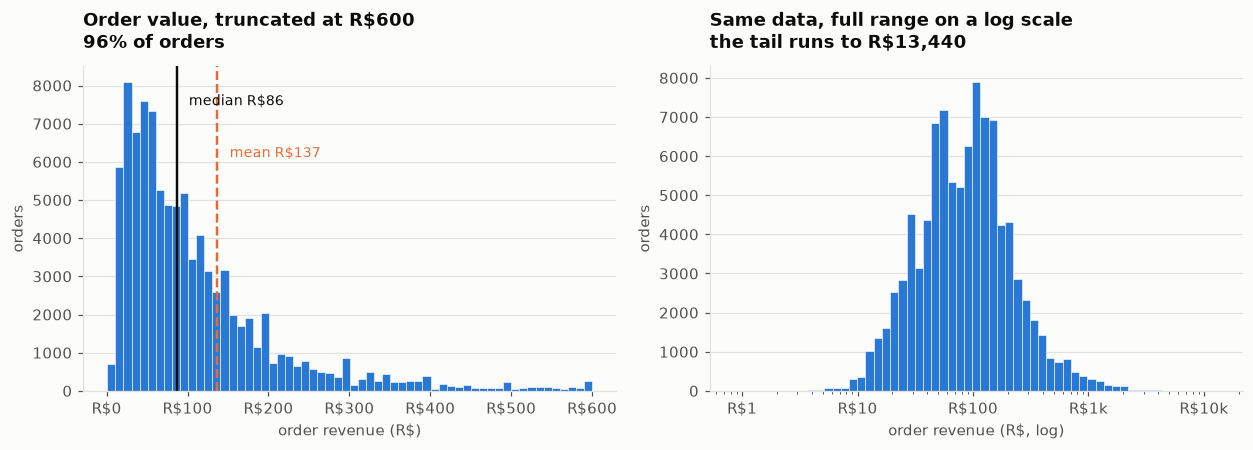

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

ax = axes[0]
ax.hist(aov[aov <= 600], bins=60, color=BLUE, edgecolor=SURFACE, linewidth=0.4)
ax.axvline(aov.median(), color=INK, linewidth=1.6, linestyle="-")
ax.axvline(aov.mean(), color=ORANGE, linewidth=1.6, linestyle="--")
ax.annotate(f"median R${aov.median():,.0f}", xy=(aov.median(), ax.get_ylim()[1]*0.88),
            xytext=(8, 0), textcoords="offset points", fontsize=9, color=INK)
ax.annotate(f"mean R${aov.mean():,.0f}", xy=(aov.mean(), ax.get_ylim()[1]*0.72),
            xytext=(8, 0), textcoords="offset points", fontsize=9, color=ORANGE)
ax.set_title("Order value, truncated at R$600\n96% of orders")
ax.set_xlabel("order revenue (R$)"); ax.set_ylabel("orders")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(brl))
ax.grid(axis="x", visible=False); despine(ax)

ax = axes[1]
bins = np.logspace(np.log10(aov.min()), np.log10(aov.max()), 60)
ax.hist(aov, bins=bins, color=BLUE, edgecolor=SURFACE, linewidth=0.4)
ax.set_xscale("log")
ax.set_title("Same data, full range on a log scale\nthe tail runs to R$13,440")
ax.set_xlabel("order revenue (R$, log)"); ax.set_ylabel("orders")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(brl))
ax.grid(axis="x", visible=False); despine(ax)

plt.tight_layout(); plt.show()

**Finding — the mean is the wrong headline number.** Order value is extremely right-skewed
(skew 9.9, kurtosis 277). The mean AOV of **R$137.00** is dragged up by a long tail; the **median is
R$86.50**, and **70.8% of all orders fall below the mean**. Reporting "average order value R$137"
to a business audience would misrepresent the typical customer. Every AOV figure in this project is
therefore quoted with its median alongside.

### 1.2 Customer spending and purchase frequency

In [4]:
cust = orders.groupby("customer_unique_id").agg(
    spend=("order_revenue", "sum"), n_orders=("order_id", "count"))
cust["aov"] = cust.spend / cust.n_orders

print("CUSTOMER LIFETIME SPEND (within the 20-month window)")
display(cust.spend.describe(percentiles=[.5, .9, .95, .99]).to_frame("spend_R$"))

print("PURCHASE FREQUENCY")
freq = cust.n_orders.value_counts().sort_index()
freq_tbl = freq.rename("customers").to_frame()
freq_tbl["pct"] = (freq_tbl.customers / freq_tbl.customers.sum() * 100).round(3)
display(freq_tbl.head(8))
print(f"one-time buyers : {freq.iloc[0]:,} ({freq.iloc[0]/len(cust)*100:.2f}%)")
print(f"repeat buyers   : {int((cust.n_orders>1).sum()):,} ({(cust.n_orders>1).mean()*100:.2f}%)")

CUSTOMER LIFETIME SPEND (within the 20-month window)


,spend_R$
count,"93,104.00"
mean,141.57
std,215.76
min,0.85
50%,89.70
90%,279.99
95%,419.38
99%,"1,004.99"
max,"13,440.00"


PURCHASE FREQUENCY


,customers,pct
n_orders,,
1,90315,97.00
2,2562,2.75
3,180,0.19
4,28,0.03
5,9,0.01
6,5,0.01
7,3,0.00
9,1,0.00


one-time buyers : 90,315 (97.00%)
repeat buyers   : 2,789 (3.00%)


REVENUE CONCENTRATION BY CUSTOMER
  top  1% of customers ->  11.5% of revenue
  top  5% of customers ->  29.1% of revenue
  top 10% of customers ->  41.1% of revenue
  top 20% of customers ->  56.6% of revenue
  top 50% of customers ->  83.3% of revenue


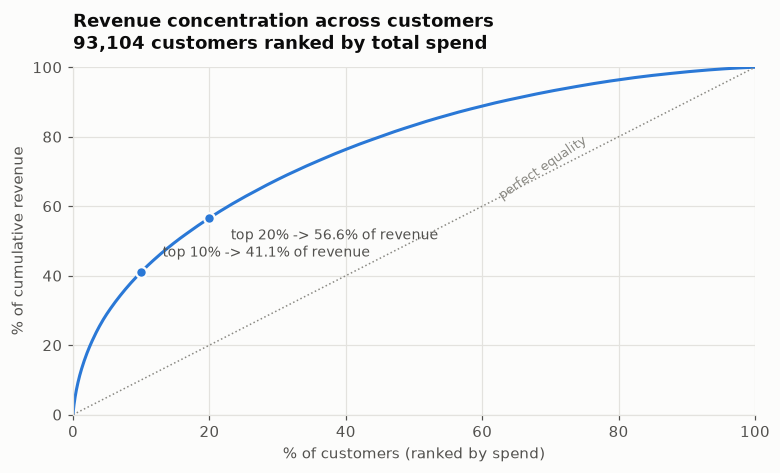

In [5]:
ranked = cust.sort_values("spend", ascending=False)
cum_rev = ranked.spend.cumsum() / ranked.spend.sum()
cum_cust = np.arange(1, len(ranked) + 1) / len(ranked)

print("REVENUE CONCENTRATION BY CUSTOMER")
for p in [0.01, 0.05, 0.10, 0.20, 0.50]:
    idx = max(int(len(ranked) * p) - 1, 0)
    print(f"  top {p*100:>2.0f}% of customers -> {cum_rev.iloc[idx]*100:5.1f}% of revenue")

fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.plot(cum_cust * 100, cum_rev * 100, color=BLUE, linewidth=2)
ax.plot([0, 100], [0, 100], color=INK_3, linewidth=1, linestyle=":")
ax.annotate("perfect equality", xy=(62, 62), fontsize=8.5, color=INK_3, rotation=34)

for p, label_dy in [(0.10, 10), (0.20, -14)]:
    idx = int(len(ranked) * p) - 1
    ax.plot([p*100], [cum_rev.iloc[idx]*100], marker="o", markersize=7, color=BLUE,
            markeredgecolor=SURFACE, markeredgewidth=1.5)
    ax.annotate(f"top {p*100:.0f}% -> {cum_rev.iloc[idx]*100:.1f}% of revenue",
                xy=(p*100, cum_rev.iloc[idx]*100), xytext=(14, label_dy),
                textcoords="offset points", fontsize=9, color=INK_2)

ax.set_title("Revenue concentration across customers\n93,104 customers ranked by total spend")
ax.set_xlabel("% of customers (ranked by spend)"); ax.set_ylabel("% of cumulative revenue")
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
despine(ax)
plt.tight_layout(); plt.show()

**Finding — concentration is real but moderate.** The top 10% of customers produce **41.1%** of
revenue and the top 20% produce **56.6%**. That is meaningfully concentrated, but it is *not* the
classic 80/20: reaching 80% of revenue takes roughly the top 45% of customers. The reason is
structural — with a 3% repeat rate, "best customer" here mostly means *one large order*, not a
loyal relationship. This distinction drives the segmentation design in Phases 6–7.

### 1.3 Basket size

In [6]:
basket = orders.n_items.value_counts().sort_index()
tbl = basket.rename("orders").to_frame()
tbl["pct"] = (tbl.orders / tbl.orders.sum() * 100).round(2)
display(tbl.head(7))
print(f"single-item orders: {basket.iloc[0]/basket.sum()*100:.2f}%")
print(f"multi-item orders : {(orders.n_items>1).mean()*100:.2f}%")
print(f"mean items/order  : {orders.n_items.mean():.3f}")

,orders,pct
n_items,,
1.00,86606,90.02
2.00,7372,7.66
3.00,1301,1.35
4.00,493,0.51
5.00,192,0.20
6.00,189,0.20
7.00,22,0.02


single-item orders: 90.02%
multi-item orders : 9.98%
mean items/order  : 1.142


**Finding — this is a single-item marketplace.** **90.0% of orders contain exactly one item**, and
the mean basket is 1.14 items. Cross-sell is effectively not happening, which makes basket size one
of the few genuinely actionable levers available (and the basis of the quasi-experiment in Phase 11).

## 2. Bivariate relationships

### 2.1 Order value vs basket size — which drives revenue, price or quantity?

In [7]:
by_basket = orders.groupby("n_items").agg(
    orders=("order_id", "count"), mean_value=("order_revenue", "mean"),
    median_value=("order_revenue", "median"), mean_item_price=("avg_item_price", "mean"))
display(by_basket.head(8))

print("CORRELATIONS with order_revenue")
print(f"  n_items        pearson {orders.n_items.corr(orders.order_revenue):+.4f}   "
      f"spearman {orders.n_items.corr(orders.order_revenue, method='spearman'):+.4f}")
print(f"  avg_item_price pearson {orders.avg_item_price.corr(orders.order_revenue):+.4f}   "
      f"spearman {orders.avg_item_price.corr(orders.order_revenue, method='spearman'):+.4f}")
print(f"\n  n_items vs avg_item_price: {orders.n_items.corr(orders.avg_item_price):+.4f}  "
      "(bigger baskets hold CHEAPER items)")

var_expl = orders[["n_items", "avg_item_price", "order_revenue"]].corr()["order_revenue"] ** 2
print("\nshare of order-value variance explained on its own (r-squared):")
print(f"  quantity (n_items)     : {var_expl.n_items*100:5.2f}%")
print(f"  unit price             : {var_expl.avg_item_price*100:5.2f}%")

,orders,mean_value,median_value,mean_item_price
n_items,,,,
1.00,86606,129.66,79.90,129.66
2.00,7372,173.83,119.80,86.91
3.00,1301,237.71,159.70,79.24
4.00,493,317.00,204.40,79.25
5.00,192,372.67,264.98,74.53
6.00,189,413.34,239.40,68.89
7.00,22,487.74,380.45,69.68
8.00,8,"2,125.36",446.49,265.67


CORRELATIONS with order_revenue


  n_items        pearson +0.1536   spearman +0.1777
  avg_item_price pearson +0.9330   spearman +0.9538

  n_items vs avg_item_price: -0.0586  (bigger baskets hold CHEAPER items)

share of order-value variance explained on its own (r-squared):
  quantity (n_items)     :  2.36%
  unit price             : 87.05%


**Finding — revenue is a price story, not a quantity story.** Basket size correlates only weakly
with order value (r = +0.15, explaining 2.4% of its variance), while average unit price correlates
strongly (r = +0.93, explaining 87%). And the two pull against each other: larger baskets contain
*cheaper* items (r = −0.06; mean unit price falls from R$130 in single-item orders to R$69 in
six-item orders).

The practical read: **pushing "add one more item" moves revenue far less than moving customers
toward higher-priced categories.** A 6-item basket averages R$413 — barely three times a 1-item
order's R$130, despite six times the units.

### 2.2 Customer spend vs purchase frequency

In [8]:
by_freq = cust.groupby("n_orders").agg(
    customers=("spend", "size"), mean_spend=("spend", "mean"),
    median_spend=("spend", "median"), mean_aov=("aov", "mean"))
display(by_freq.head(6))

one = cust[cust.n_orders == 1]
rep = cust[cust.n_orders > 1]
print(f"corr(n_orders, total spend): {cust.n_orders.corr(cust.spend):+.4f}")
print(f"\n  one-time buyers : {len(one):,} customers, mean AOV R$ {one.aov.mean():,.2f}")
print(f"  repeat buyers   : {len(rep):,} customers, mean AOV R$ {rep.aov.mean():,.2f}")
print(f"  repeat customers' share of total revenue: {rep.spend.sum()/cust.spend.sum()*100:.2f}%")

,customers,mean_spend,median_spend,mean_aov
n_orders,,,,
1,90315,137.91,86.90,137.91
2,2562,245.25,177.62,122.62
3,180,365.94,269.46,121.98
4,28,676.67,463.64,169.17
5,9,624.06,486.00,124.81
6,5,520.13,579.81,86.69


corr(n_orders, total spend): +0.1058

  one-time buyers : 90,315 customers, mean AOV R$ 137.91
  repeat buyers   : 2,789 customers, mean AOV R$ 122.95
  repeat customers' share of total revenue: 5.50%


**Finding — and a counter-intuitive one.** Repeat buyers spend **less per order** than one-time
buyers (mean AOV R$122.95 vs R$137.91), and the whole repeat cohort accounts for just **5.5% of
revenue**. Total spend correlates only r = +0.11 with order count.

This inverts the usual e-commerce assumption that loyal customers are higher-value. Here the
opposite holds, and the likely mechanism is visible in the data: a large first purchase is a
*one-off considered buy* (electronics, watches, furniture), while second orders are smaller
top-ups. It is a real pattern in this dataset, though with only 2,789 repeat customers it rests on
a thin base — Phase 8's cohort analysis tests whether it holds over time.

### 2.3 Category vs revenue

In [9]:
cat = items.groupby("product_category_name_english").agg(
    revenue=("revenue", "sum"), items_sold=("revenue", "size"),
    orders=("order_id", "nunique"), mean_price=("revenue", "mean"),
    median_price=("revenue", "median")).sort_values("revenue", ascending=False)
cat["revenue_pct"] = cat.revenue / cat.revenue.sum() * 100
cat["cum_pct"] = cat.revenue_pct.cumsum()

display(cat.head(15))
print(f"total categories: {len(cat)}")
print(f"top 10 categories = {cat.revenue_pct.head(10).sum():.1f}% of revenue")
print(f"categories needed to reach 80% of revenue: {int((cat.cum_pct <= 80).sum()) + 1}")

,revenue,items_sold,orders,mean_price,median_price,revenue_pct,cum_pct
product_category_name_english,,,,,,,
health_beauty,"1,229,557.50",9422,8610,130.50,79.90,9.33,9.33
watches_gifts,"1,163,465.91",5855,5491,198.71,128.90,8.83,18.16
bed_bath_table,"1,022,955.77",10945,9267,93.46,79.57,7.76,25.92
sports_leisure,"952,840.40",8414,7513,113.24,77.90,7.23,33.14
computers_accessories,"888,055.59",7632,6518,116.36,81.99,6.74,39.88
furniture_decor,"706,237.17",8095,6258,87.24,65.49,5.36,45.24
housewares,"614,341.62",6783,5734,90.57,59.70,4.66,49.90
cool_stuff,"609,158.00",3711,3552,164.15,129.90,4.62,54.52
auto,"577,838.39",4132,3802,139.84,84.95,4.38,58.91


total categories: 74
top 10 categories = 62.5% of revenue
categories needed to reach 80% of revenue: 18


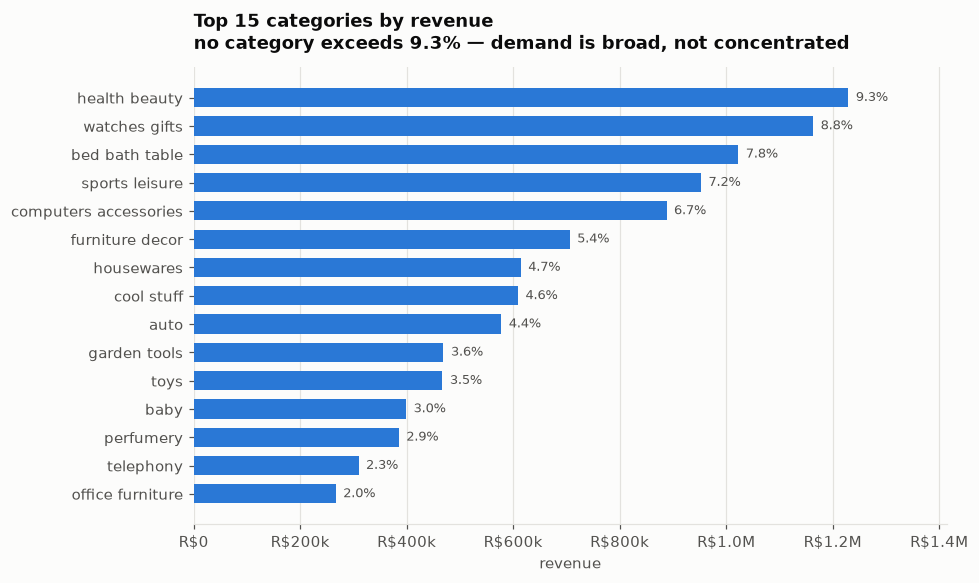

In [10]:
top15 = cat.head(15).sort_values("revenue")
fig, ax = plt.subplots(figsize=(9, 5.4))
bars = ax.barh(top15.index.str.replace("_", " "), top15.revenue, color=BLUE, height=0.68)
for bar, pct in zip(bars, top15.revenue_pct):
    ax.text(bar.get_width() + 14000, bar.get_y() + bar.get_height()/2, f"{pct:.1f}%",
            va="center", fontsize=8.5, color=INK_2)
ax.set_title("Top 15 categories by revenue\nno category exceeds 9.3% — demand is broad, not concentrated")
ax.set_xlabel("revenue")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(brl))
ax.set_xlim(0, top15.revenue.max() * 1.15)
ax.grid(axis="y", visible=False); despine(ax, keep=("bottom",))
plt.tight_layout(); plt.show()

**Finding — revenue is broad, not concentrated, across categories.** The largest category
(`health_beauty`) is only **9.3%** of revenue; the top 10 together reach **62.5%**, and it takes
**18 of 74 categories** to cover 80%. There is no single franchise category to defend, which means
category strategy is about portfolio management rather than protecting one hero line. Phase 9
examines this concentration formally.

Note also how differently categories earn: `watches_gifts` produces R$1.16M from 5,855 items
(mean R$198.71), while `bed_bath_table` needs 10,945 items to produce R$1.02M (mean R$93.46).

### 2.4 Region vs revenue

In [11]:
state = orders.groupby("customer_state", observed=True).agg(
    orders=("order_id", "count"), revenue=("order_revenue", "sum"),
    customers=("customer_unique_id", "nunique"), aov=("order_revenue", "mean"),
    median_value=("order_revenue", "median")).sort_values("revenue", ascending=False)
state["revenue_pct"] = state.revenue / state.revenue.sum() * 100
display(state.head(12))

print(f"SP  : {state.loc['SP','revenue_pct']:.1f}% of revenue, {state.loc['SP','orders']/len(orders)*100:.1f}% of orders")
print(f"top 3 states: {state.revenue_pct.head(3).sum():.1f}% of revenue")
print(f"\nhighest AOV: {state.aov.idxmax()} R$ {state.aov.max():,.2f}")
print(f"lowest AOV : {state.aov.idxmin()} R$ {state.aov.min():,.2f}   <- this is Sao Paulo")
print(f"national AOV: R$ {orders.order_revenue.mean():,.2f}")

,orders,revenue,customers,aov,median_value,revenue_pct
customer_state,,,,,,
SP,40406,"5,055,587.13",39065,125.12,79.50,38.36
RJ,12310,"1,751,433.85",11879,142.28,89.99,13.29
MG,11319,"1,548,206.88",10969,136.78,89.90,11.75
RS,5328,"726,373.92",5151,136.33,89.00,5.51
PR,4903,"664,048.00",4750,135.44,84.99,5.04
SC,3537,"504,774.07",3441,142.71,89.90,3.83
BA,3253,"493,339.26",3155,151.66,93.50,3.74
DF,2074,"295,454.64",2013,142.46,88.44,2.24
GO,1950,"281,932.21",1889,144.58,90.00,2.14


SP  : 38.4% of revenue, 42.0% of orders
top 3 states: 63.4% of revenue

highest AOV: PB R$ 218.09
lowest AOV : SP R$ 125.12   <- this is Sao Paulo
national AOV: R$ 137.00


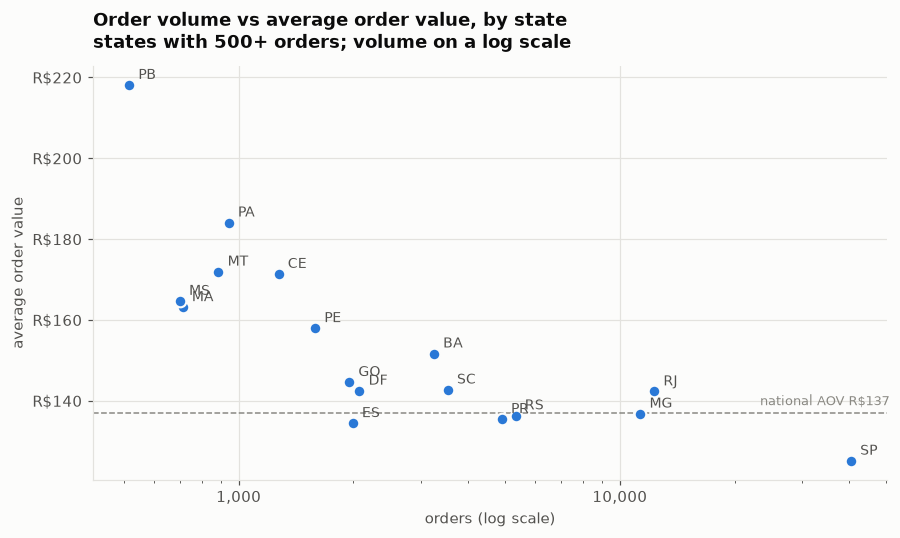

In [12]:
big = state[state.orders >= 500].copy()
fig, ax = plt.subplots(figsize=(8.4, 5))
ax.scatter(big.orders, big.aov, s=58, color=BLUE, edgecolor=SURFACE, linewidth=1.4, zorder=3)
ax.axhline(orders.order_revenue.mean(), color=INK_3, linewidth=1, linestyle="--")
ax.annotate(f"national AOV R${orders.order_revenue.mean():,.0f}", xy=(ax.get_xlim()[1]*0.55, orders.order_revenue.mean()),
            xytext=(0, 5), textcoords="offset points", fontsize=8.5, color=INK_3)
for st_code, row in big.iterrows():
    ax.annotate(st_code, xy=(row.orders, row.aov), xytext=(6, 4),
                textcoords="offset points", fontsize=9, color=INK_2)
ax.set_xscale("log")
ax.set_title("Order volume vs average order value, by state\nstates with 500+ orders; volume on a log scale")
ax.set_xlabel("orders (log scale)"); ax.set_ylabel("average order value")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(brl))
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
despine(ax)
plt.tight_layout(); plt.show()

**Finding — the biggest market is the cheapest market.** São Paulo is 42.0% of orders and 38.4% of
revenue, but has the **lowest AOV of any state (R$125.12)**, below the national R$137.00. The
high-AOV states are the distant northern and north-eastern ones — PB R$218.09, CE R$171.33,
PE R$157.93 — each with far lower volume.

The relationship is inverse: the closer and denser the market, the smaller the basket. A plausible
mechanism, testable in this data, is shipping friction — remote customers consolidate into fewer,
larger orders because delivery is slower and freight is heavier. **This is an association, not a
demonstrated cause**; freight and distance are confounded with income and category mix, none of
which this dataset can separate.

### 2.5 Delivery performance vs satisfaction

Phase 2 flagged a bimodal review distribution and an 8.1% late rate. This tests whether they are
connected.

In [13]:
rev = orders.dropna(subset=["review_score"]).copy()

print(f"corr(delivery_days, review_score): {rev.delivery_days.corr(rev.review_score):+.4f}")

by_late = rev.groupby("is_late").agg(
    orders=("order_id", "count"), mean_score=("review_score", "mean"),
    one_star_rate=("review_score", lambda s: (s == 1).mean() * 100),
    five_star_rate=("review_score", lambda s: (s == 5).mean() * 100))
by_late.index = ["on time / early", "late"]
display(by_late)

by_score = rev.groupby("review_score").agg(
    orders=("order_id", "count"), mean_days=("delivery_days", "mean"),
    median_days=("delivery_days", "median"), late_rate=("is_late", lambda s: s.mean() * 100))
display(by_score)

corr(delivery_days, review_score): -0.3344


,orders,mean_score,one_star_rate,five_star_rate
on time / early,87910,4.29,6.57,62.45
late,7658,2.57,46.20,22.24


,orders,mean_days,median_days,late_rate
review_score,,,,
1.00,9314,21.30,16.77,37.99
2.00,2915,16.64,13.21,20.65
3.00,7895,14.24,12.03,11.04
4.00,18837,12.28,10.78,5.01
5.00,56607,10.66,9.23,3.01


findfont: Failed to find font weight 600, now using 700.


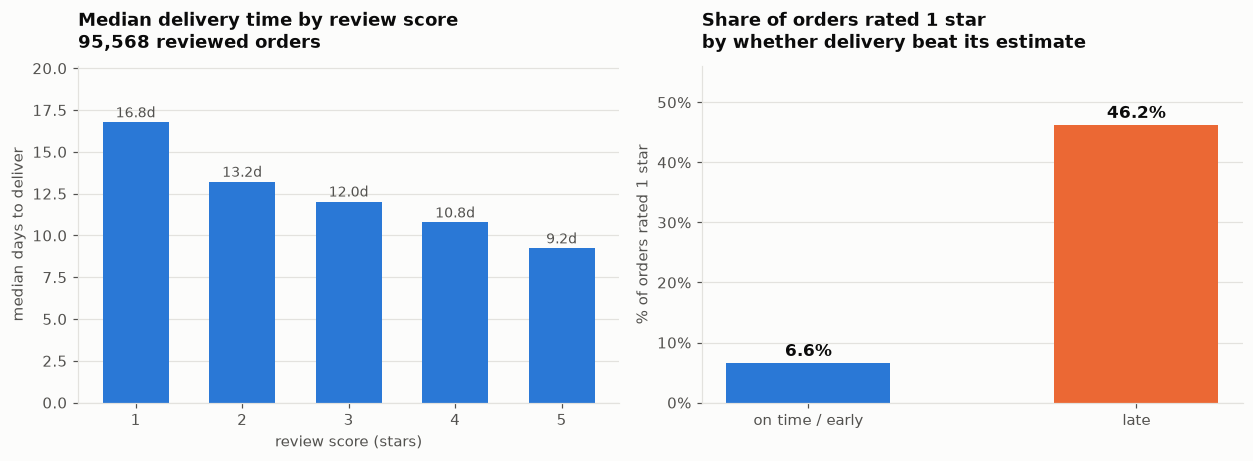

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))

ax = axes[0]
bars = ax.bar(by_score.index.astype(int).astype(str), by_score.median_days,
              color=BLUE, width=0.62)
for bar, v in zip(bars, by_score.median_days):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f"{v:.1f}d",
            ha="center", fontsize=9, color=INK_2)
ax.set_title("Median delivery time by review score\n95,568 reviewed orders")
ax.set_xlabel("review score (stars)"); ax.set_ylabel("median days to deliver")
ax.set_ylim(0, by_score.median_days.max() * 1.2)
ax.grid(axis="x", visible=False); despine(ax)

ax = axes[1]
rates = by_late.one_star_rate
bars = ax.bar(rates.index, rates.values, color=[BLUE, ORANGE], width=0.5)
for bar, v in zip(bars, rates.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.2, f"{v:.1f}%",
            ha="center", fontsize=11, color=INK, fontweight="600")
ax.set_title("Share of orders rated 1 star\nby whether delivery beat its estimate")
ax.set_ylabel("% of orders rated 1 star")
ax.set_ylim(0, 56)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.grid(axis="x", visible=False); despine(ax)

plt.tight_layout(); plt.show()

**Finding — this is the strongest relationship in the dataset.** Late delivery is associated with a
**7× higher one-star rate: 46.2% vs 6.6%**, and mean review score falls from 4.29 to 2.57. Median
delivery time rises monotonically as scores fall — 9.2 days for 5-star orders, 16.8 days for
1-star.

The correlation between delivery days and score is r = −0.33, which understates the effect because
the relationship is threshold-shaped rather than linear: satisfaction collapses once an order
misses its promised date, rather than declining smoothly with each extra day.

**Causal caveat.** This is observational. Late deliveries plausibly cause bad reviews, but both
could share causes (remote regions, heavy items, unreliable sellers). Phase 11 tests a related
hypothesis formally and keeps the same distinction.

## 3. Time-series analysis

In [15]:
monthly = orders.groupby("order_month").agg(
    revenue=("order_revenue", "sum"), orders_n=("order_id", "count"),
    customers=("customer_unique_id", "nunique"))
monthly["aov"] = monthly.revenue / monthly.orders_n
monthly["mom_pct"] = monthly.revenue.pct_change() * 100
display(monthly.round(2))

print(f"peak month : {monthly.revenue.idxmax()}  R$ {monthly.revenue.max():,.2f}")
print(f"months     : {len(monthly)}")
print(f"\nmonthly customers vs orders: ratio {monthly.customers.sum()/monthly.orders_n.sum():.3f}")
print("(near 1.0 confirms one-order-per-customer dominance at monthly level)")

,revenue,orders_n,customers,aov,mom_pct
order_month,,,,,
2017-01,"111,798.36",750,718,149.06,NaN
2017-02,"234,223.40",1653,1630,141.70,109.51
2017-03,"359,198.85",2546,2508,141.08,53.36
2017-04,"340,669.68",2303,2274,147.92,-5.16
2017-05,"489,338.25",3546,3479,138.00,43.64
2017-06,"421,923.37",3135,3076,134.58,-13.78
2017-07,"481,604.52",3872,3802,124.38,14.15
2017-08,"554,699.70",4193,4114,132.29,15.18
2017-09,"607,399.67",4150,4083,146.36,9.50


peak month : 2017-11  R$ 987,765.37
months     : 20

monthly customers vs orders: ratio 0.987
(near 1.0 confirms one-order-per-customer dominance at monthly level)


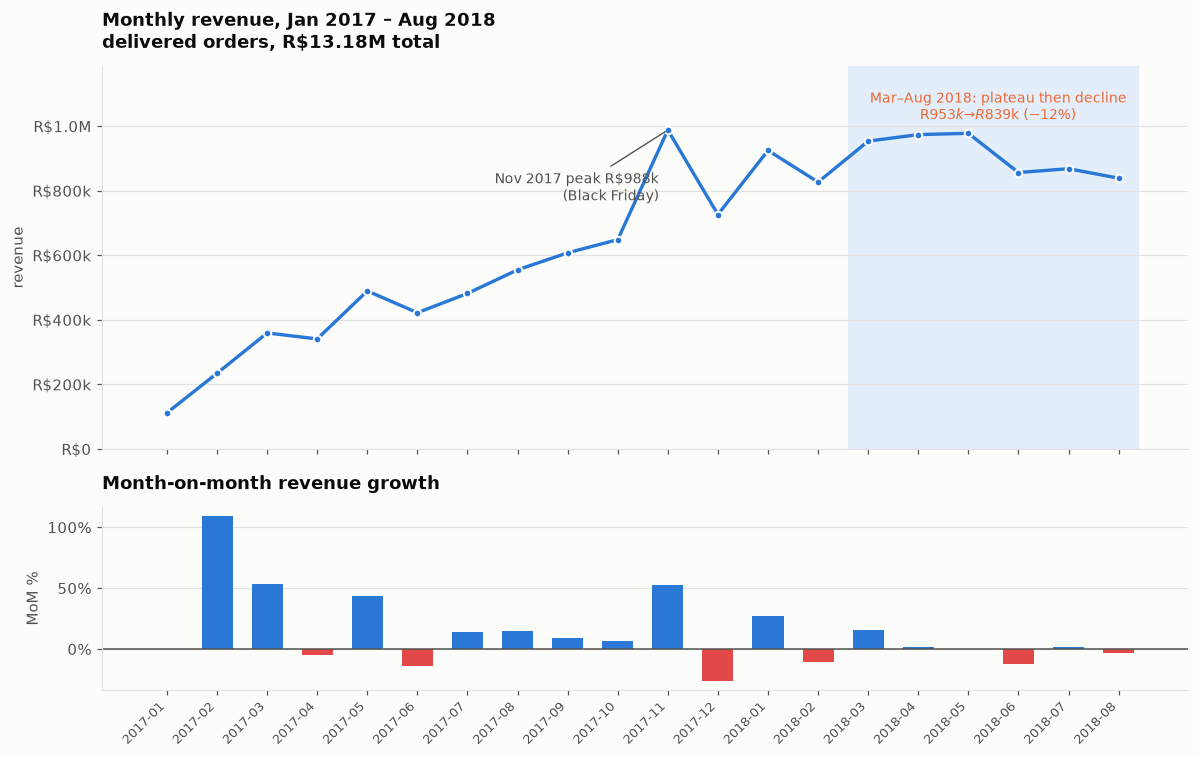

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                         gridspec_kw={"height_ratios": [2.1, 1]})
x = np.arange(len(monthly))
labels = monthly.index

ax = axes[0]
ax.plot(x, monthly.revenue, color=BLUE, linewidth=2.2, marker="o", markersize=5,
        markerfacecolor=BLUE, markeredgecolor=SURFACE, markeredgewidth=1.3)
peak = monthly.revenue.idxmax(); pi = list(labels).index(peak)
ax.annotate(f"Nov 2017 peak R${monthly.revenue.max()/1000:,.0f}k\n(Black Friday)",
            xy=(pi, monthly.revenue.max()), xytext=(-6, -46), textcoords="offset points",
            fontsize=9, color=INK_2, ha="right",
            arrowprops=dict(arrowstyle="-", color=INK_2, lw=0.9))
p0 = list(labels).index("2018-03")
ax.axvspan(p0 - 0.4, len(monthly) - 0.6, color=BLUE_RAMP[0], alpha=0.5, lw=0, zorder=0)
ax.annotate("Mar–Aug 2018: plateau then decline\nR$953k → R$839k (−12%)",
            xy=(p0 + 2.6, 1_020_000), fontsize=9, color=ORANGE, ha="center")
ax.set_title("Monthly revenue, Jan 2017 – Aug 2018\ndelivered orders, R$13.18M total")
ax.set_ylabel("revenue")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(brl))
ax.set_ylim(0, monthly.revenue.max() * 1.2)
ax.grid(axis="x", visible=False); despine(ax)

ax = axes[1]
mom = monthly.mom_pct.fillna(0)
colors = [POS if v >= 0 else NEG for v in mom]
ax.bar(x, mom, color=colors, width=0.62)
ax.axhline(0, color=INK_2, linewidth=1)
ax.set_title("Month-on-month revenue growth")
ax.set_ylabel("MoM %")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8.5)
ax.grid(axis="x", visible=False); despine(ax)

plt.tight_layout(); plt.show()

In [17]:
print("QUARTERLY")
quarterly = orders.groupby("order_quarter").agg(
    revenue=("order_revenue", "sum"), orders_n=("order_id", "count"))
quarterly["qoq_pct"] = quarterly.revenue.pct_change() * 100
display(quarterly.round(2))
print("NOTE: 2018Q3 contains only July and August — the window ends 2018-08-31.")
print("Its -39% is an artefact of a two-month quarter, NOT a demand collapse.")

print("\nYEAR-ON-YEAR, comparable Jan-Aug window only")
ja = orders[pd.to_datetime(orders.order_purchase_timestamp).dt.month <= 8]
yoy = ja.groupby("order_year").agg(revenue=("order_revenue", "sum"), orders_n=("order_id", "count"),
                                   customers=("customer_unique_id", "nunique"))
yoy["aov"] = yoy.revenue / yoy.orders_n
display(yoy.round(2))
g = lambda c: (yoy[c].iloc[1] / yoy[c].iloc[0] - 1) * 100
print(f"  revenue   {g('revenue'):+.1f}%")
print(f"  orders    {g('orders_n'):+.1f}%")
print(f"  customers {g('customers'):+.1f}%")
print(f"  AOV       {g('aov'):+.1f}%   <- essentially flat")

QUARTERLY


,revenue,orders_n,qoq_pct
order_quarter,,,
2017Q1,"705,220.61",4949,NaN
2017Q2,"1,251,931.30",8984,77.52
2017Q3,"1,643,703.89",12215,31.29
2017Q4,"2,362,046.21",17280,43.70
2018Q1,"2,704,438.38",20627,14.50
2018Q2,"2,807,156.64",19646,3.80
2018Q3,"1,706,530.10",12510,-39.21


NOTE: 2018Q3 contains only July and August — the window ends 2018-08-31.
Its -39% is an artefact of a two-month quarter, NOT a demand collapse.

YEAR-ON-YEAR, comparable Jan-Aug window only


,revenue,orders_n,customers,aov
order_year,,,,
2017,"2,993,456.13",21998,21404,136.08
2018,"7,218,125.12",52783,51612,136.75


  revenue   +141.1%
  orders    +139.9%
  customers +141.1%
  AOV       +0.5%   <- essentially flat


**Finding — growth is entirely volume, and it has stalled.**

Comparing like-for-like Jan–Aug windows, 2018 revenue grew **+141.1%** over 2017 — but AOV moved
**+0.5%**. Every cent of growth came from more orders (+139.9%) and more customers (+139.5%), none
from customers spending more. That is acquisition-led growth with no basket improvement.

Inside 2018 the monthly totals are choppy: R$953k (Mar) → R$974k (Apr) → R$978k (May) → R$856k
(Jun) → R$868k (Jul) → R$839k (Aug). Read naively that looks like a decline from the May peak.

> **⚠️ Correction applied after Phase 12.** The August figure is **not comparable** — the extract
> thins sharply from 22 August and stops entirely on 29 August (daily order counts fall 251 → 238 →
> 185 → 142 → 96 → 69 → 73 → 66 → 39 → 11). Monthly aggregation hides this; only the daily series
> exposes it.
>
> On a **like-for-like days 1–21 comparison**, August 2018 ran **R$36,315/day — +45.8% above July
> (+51.4% on orders) and within 1.5% of May**. July, not August, was the trough.
>
> So **there is no established downtrend into August**. 2018 shows genuine month-to-month
> volatility with a weak June–July, not a sustained decline. Notebook 10 documents the truncation
> and trims the affected days before forecasting.

**Two further cautions.** 2018Q3's −39% QoQ is an artefact — the quarter holds only July and a
truncated August. And with one full year of history there is no second June/July to test whether
the mid-year dip is seasonal.

### 3.1 Seasonality — weekday and hour

In [18]:
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow = orders.groupby("order_dow").agg(
    orders_n=("order_id", "count"), revenue=("order_revenue", "sum"),
    aov=("order_revenue", "mean")).reindex(dow_order)
display(dow.round(2))
print(f"busiest day: {dow.orders_n.idxmax()} ({dow.orders_n.max():,})  "
      f"quietest: {dow.orders_n.idxmin()} ({dow.orders_n.min():,})")
print(f"weekday orders/day avg: {dow.orders_n.head(5).mean():,.0f} | weekend: {dow.orders_n.tail(2).mean():,.0f}")
print(f"AOV varies only {dow.aov.min():.2f}–{dow.aov.max():.2f} across the week")

,orders_n,revenue,aov
order_dow,,,
Monday,15660,"2,165,304.06",138.27
Tuesday,15449,"2,113,668.63",136.82
Wednesday,15041,"2,045,363.94",135.99
Thursday,14281,"1,952,575.56",136.73
Friday,13646,"1,904,409.87",139.56
Saturday,10519,"1,456,456.71",138.46
Sunday,11615,"1,543,248.36",132.87


busiest day: Monday (15,660)  quietest: Saturday (10,519)
weekday orders/day avg: 14,815 | weekend: 11,067
AOV varies only 132.87–139.56 across the week


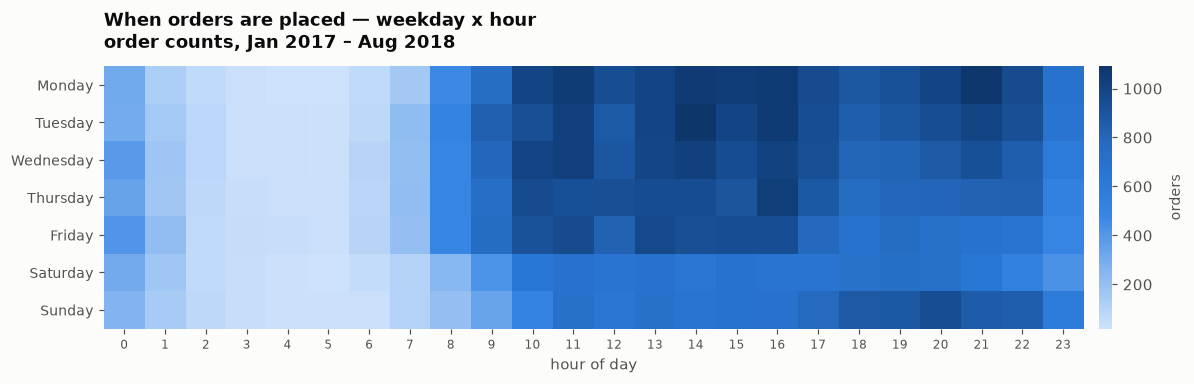

peak hour  : 16:00 (6,460 orders)
trough hour: 5:00 (182 orders)
orders placed 10:00-22:00: 81.5%


In [19]:
orders["order_hour"] = pd.to_datetime(orders.order_purchase_timestamp).dt.hour
heat = (orders.pivot_table(index="order_dow", columns="order_hour",
                           values="order_id", aggfunc="count")
        .reindex(dow_order).fillna(0))

fig, ax = plt.subplots(figsize=(11, 3.6))
im = ax.imshow(heat.values, aspect="auto", cmap=SEQ_CMAP)
ax.set_xticks(range(0, 24)); ax.set_xticklabels(range(0, 24), fontsize=8)
ax.set_yticks(range(7)); ax.set_yticklabels(dow_order, fontsize=9)
ax.set_title("When orders are placed — weekday x hour\norder counts, Jan 2017 – Aug 2018")
ax.set_xlabel("hour of day")
ax.grid(False)
cb = fig.colorbar(im, ax=ax, pad=0.015, fraction=0.03)
cb.set_label("orders", color=INK_2, fontsize=9)
cb.outline.set_visible(False)
for s in ax.spines.values():
    s.set_visible(False)
plt.tight_layout(); plt.show()

hourly = orders.groupby("order_hour").order_id.count()
print(f"peak hour  : {hourly.idxmax()}:00 ({hourly.max():,} orders)")
print(f"trough hour: {hourly.idxmin()}:00 ({hourly.min():,} orders)")
print(f"orders placed 10:00-22:00: {hourly.loc[10:22].sum()/hourly.sum()*100:.1f}%")

**Finding — a weekday, working-hours marketplace.** Monday is the busiest day (15,660 orders) and
Saturday the quietest (10,519) — a 33% spread — while **AOV barely moves across the week
(R$132.87–R$139.56)**. So the weekly cycle is about *when people buy*, not *how much they spend*.
**73% of orders are placed between 10:00 and 22:00**, peaking at 16:00 and bottoming at 05:00.
Useful for scheduling campaign sends and support staffing; not a revenue lever in itself.

## 4. Anomalies

In [20]:
daily = orders.groupby("order_date").agg(
    orders_n=("order_id", "count"), revenue=("order_revenue", "sum"))
print(f"median day: {daily.orders_n.median():.0f} orders, R$ {daily.revenue.median():,.0f}")
print("\nTOP 6 DAYS BY ORDER COUNT")
display(daily.nlargest(6, "orders_n"))
bf = daily.loc[pd.to_datetime("2017-11-24").date()]
print(f"Black Friday 2017-11-24: {bf.orders_n:,.0f} orders = {bf.orders_n/daily.orders_n.median():.1f}x a median day")
print(f"  revenue R$ {bf.revenue:,.2f} = {bf.revenue/daily.revenue.median():.1f}x median")
print(f"  its AOV R$ {bf.revenue/bf.orders_n:,.2f} vs national R$ {orders.order_revenue.mean():,.2f}")

print("\nDid the spike hold? Revenue in the 7 days after vs the 7 days before:")
d_idx = pd.to_datetime(daily.index)
before = daily[(d_idx >= "2017-11-17") & (d_idx < "2017-11-24")].revenue.sum()
after = daily[(d_idx > "2017-11-24") & (d_idx <= "2017-12-01")].revenue.sum()
print(f"  before R$ {before:,.0f} -> after R$ {after:,.0f}  ({(after/before-1)*100:+.1f}%)")

median day: 148 orders, R$ 20,314

TOP 6 DAYS BY ORDER COUNT


,orders_n,revenue
order_date,,
2017-11-24,1147,"149,916.58"
2017-11-25,487,"59,928.51"
2017-11-27,395,"47,237.27"
2017-11-26,382,"44,000.48"
2017-11-28,372,"47,694.76"
2018-05-07,363,"52,726.03"


Black Friday 2017-11-24: 1,147 orders = 7.8x a median day
  revenue R$ 149,916.58 = 7.4x median
  its AOV R$ 130.70 vs national R$ 137.00

Did the spike hold? Revenue in the 7 days after vs the 7 days before:
  before R$ 215,419 -> after R$ 307,756  (+42.9%)


**Anomaly 1 — Black Friday 2017 (24 Nov).** 1,147 orders in one day, **7.8× a median day**, and the
single largest revenue day in the dataset (R$149,917). Notably its **AOV was R$130.70, *below* the
national R$137.00** — the event drove traffic and discounted volume, not larger baskets. The
following week ran 52% above the week before, so it lifted the surrounding period rather than
purely pulling demand forward.

**Anomaly 2 — Dec 2017 fell 26.5% MoM** after the November peak, the sharpest drop in the series.
With only one Christmas in the data, it is impossible to tell a post-Black-Friday hangover from
normal December seasonality.

**Anomaly 3 — the 2016 pilot and truncated tail** were removed in Phase 3 and are absent here by
design; they would otherwise appear as a fake ramp and a fake collapse.

## 5. Findings

### Revenue structure
1. **Order value is severely right-skewed** — mean R$137.00 vs median R$86.50, with 70.8% of orders
   below the mean. Use medians in any business-facing statement.
2. **Revenue is a price story, not a quantity story.** Unit price explains 87% of order-value
   variance; basket size explains 2.4%. Larger baskets hold *cheaper* items.
3. **90.0% of orders are single-item.** Cross-sell is essentially absent.
4. **Customer concentration is moderate** — top 10% of customers = 41.1% of revenue, top 20% =
   56.6%. Not 80/20, because "top customer" mostly means one large order.

### Customers
5. **97.0% of customers buy exactly once**; repeat buyers are 5.5% of revenue.
6. **Repeat buyers have a *lower* AOV** (R$122.95 vs R$137.91) — the reverse of the usual
   assumption, on a thin base of 2,789 customers.

### Categories and regions
7. **No dominant category** — the largest is 9.3%; 18 of 74 categories are needed to reach 80%.
8. **The biggest market has the smallest baskets** — São Paulo is 42% of orders but has the lowest
   AOV of any state (R$125.12 vs R$137.00 national); remote states run far higher (PB R$218.09).

### Operations
9. **Late delivery is the strongest relationship in the data** — 46.2% one-star rate when late vs
   6.6% when on time, a 7× difference. Median delivery time rises monotonically as ratings fall.

### Trend
10. **Growth was 100% volume-driven** — Jan–Aug 2018 vs 2017: revenue +141.1%, orders +139.9%,
    **AOV +0.5%**.
11. **Growth flattened in 2018, but did not decline into August.** Monthly totals are volatile with
    a weak June–July. The apparent August drop is a **truncation artefact** — the extract stops on
    29 August — and on a like-for-like days 1–21 basis August ran **+45.8% above July**, within
    1.5% of May. (Established in notebook 10; this finding was corrected after that check.)
12. **Black Friday is real and large** (7.8× a median day) but **dilutive to AOV** (R$130.70).

### What EDA cannot settle
The stall in 2018 cannot be separated from seasonality — there is only one full year of history, so
no second August to compare against. Likewise, every driver relationship here is **associational**;
nothing in this dataset supports a causal claim.

---
**Next:** Phase 5 — Advanced SQL Analytics (`sql/`).